In [ ]:
!pip install torch_geometric
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-$(torch.__version__).html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.1 MB/s eta 0:00:00
/bin/bash: line 1: torch.__version__: command not found
Looking in links: https://data.pyg.org/whl/torch-.html
ERROR: Could not find a version that satisfies the requirement pyg_lib (from versions: none)
ERROR: No matching distribution found for pyg_lib


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import random
import ast
from itertools import combinations
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import resample

# ── Config ────────────────────────────────────────────────────────────────
SEED       = 42
EMB_DIM    = 64
BATCH      = 128
EPOCHS     = 40
MAX_VISITS = 3
MIN_SAMPLES= 20
QUICK_RUN  = False   # Set True to test on small subset first

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Load & Clean ──────────────────────────────────────────────────────────
df = pd.read_csv('fixed_augmented_dataset_multibiner_num_augmentations_100_cleaned.csv')
df.fillna(0, inplace=True)
print(f"Loaded: {df.shape}")

DISEASE_COL  = 'prognosis'
SYMPTOMS_COL = 'symptoms'

drop_cols    = [c for c in [DISEASE_COL, SYMPTOMS_COL] if c in df.columns]
symptom_cols = [c for c in df.columns if c not in drop_cols]

# Parse symptoms
if 'symptoms' in df.columns:
    def parse_symptoms(val):
        if isinstance(val, list): return [s.strip().lower() for s in val]
        try:    return [s.strip().lower() for s in ast.literal_eval(val)]
        except: return []
    df['symptom_list'] = df['symptoms'].apply(parse_symptoms)
else:
    df['symptom_list'] = df.apply(
        lambda row: [c.lower() for c in symptom_cols if row[c] == 1], axis=1)

df = df[df['symptom_list'].map(len) > 0].reset_index(drop=True)
df['disease'] = df[DISEASE_COL].astype(str).str.strip().str.lower()
print(f"Classes: {df['disease'].nunique()}  Rows: {len(df)}")

# ── Oversample ────────────────────────────────────────────────────────────
groups = []
for cls, grp in df.groupby('disease'):
    if len(grp) < MIN_SAMPLES:
        grp = resample(grp, replace=True, n_samples=MIN_SAMPLES, random_state=SEED)
    groups.append(grp)
df = pd.concat(groups).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"After oversample: {len(df)}")

# ── Symptom vocab & Graph ─────────────────────────────────────────────────
all_symptoms = sorted(set(s for row in df['symptom_list'] for s in row))
symptom2idx  = {s: i for i, s in enumerate(all_symptoms)}
NUM_SYMPTOMS = len(symptom2idx)
print(f"Unique symptoms: {NUM_SYMPTOMS}")

edge_set = set()
for symptoms in df['symptom_list']:
    idxs = [symptom2idx[s] for s in symptoms if s in symptom2idx]
    for i, j in combinations(idxs, 2):
        edge_set.add((i, j)); edge_set.add((j, i))

src, dst   = zip(*edge_set) if edge_set else ([], [])
edge_index = torch.tensor([list(src), list(dst)], dtype=torch.long).to(device)
print(f"Graph edges: {edge_index.shape[1]}")

# ── EHR Simulation (done ONCE, outside loop) ──────────────────────────────
def simulate_ehr(symptoms):
    unique = list(set(symptoms))
    n_vis  = np.random.randint(2, MAX_VISITS + 1)
    visits, t = [], 0.0
    for _ in range(n_vis):
        k     = np.random.randint(1, min(4, len(unique)) + 1)
        syms  = list(np.random.choice(unique, size=k, replace=True))
        t    += float(np.random.randint(1, 15))
        visits.append((syms, t))
    return visits

print("Simulating EHR...");
ehr_data = [simulate_ehr(s) for s in df['symptom_list']]
print("Done.")

# ── Labels & Split ────────────────────────────────────────────────────────
le          = LabelEncoder()
labels      = le.fit_transform(df['disease'])
NUM_CLASSES = len(le.classes_)
print(f"Total classes: {NUM_CLASSES}")

X_train, X_test, y_train, y_test = train_test_split(
    ehr_data, labels, test_size=0.2, random_state=SEED, stratify=labels)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

if QUICK_RUN:
    X_train, y_train = X_train[:400], y_train[:400]
    X_test,  y_test  = X_test[:100],  y_test[:100]
    print("QUICK_RUN enabled — using subset")

# ── Model ─────────────────────────────────────────────────────────────────
class SymptomGNN(nn.Module):
    def __init__(self, num_nodes, emb_dim):
        super().__init__()
        self.emb   = nn.Embedding(num_nodes, emb_dim)
        self.conv1 = GCNConv(emb_dim, emb_dim)
        self.conv2 = GCNConv(emb_dim, emb_dim)
        self.act   = nn.ReLU()
    def forward(self, edge_index):
        x = self.emb.weight
        x = self.act(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class TimeAwareTransformer(nn.Module):
    def __init__(self, emb_dim, nhead=4, num_layers=2):
        super().__init__()
        self.time_fc = nn.Sequential(
            nn.Linear(1, emb_dim), nn.ReLU(), nn.Linear(emb_dim, emb_dim))
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=nhead, batch_first=True,
            dim_feedforward=emb_dim * 2, dropout=0.1)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.attn_fc = nn.Linear(emb_dim, 1)
    def forward(self, x, times):
        t_norm   = (times - times.min()) / (times.max() - times.min() + 1e-8)
        time_emb = self.time_fc(t_norm.unsqueeze(-1))
        x        = x + time_emb.unsqueeze(0)
        out      = self.encoder(x)
        weights  = torch.softmax(self.attn_fc(out), dim=1)
        return (out * weights).sum(dim=1), weights

class DiseaseModel(nn.Module):
    def __init__(self, num_symptoms, num_classes, emb_dim=EMB_DIM):
        super().__init__()
        self.gnn      = SymptomGNN(num_symptoms, emb_dim)
        self.temporal = TimeAwareTransformer(emb_dim)
        self.dropout  = nn.Dropout(0.3)
        self.fc       = nn.Linear(emb_dim, num_classes)

    def forward(self, ehr_batch, sym_emb):   # sym_emb passed in — NOT recomputed
        vecs, attns = [], []
        for visits in ehr_batch:
            v_list, t_list = [], []
            for (syms, t) in visits[:MAX_VISITS]:
                idxs = [symptom2idx[s] for s in syms if s in symptom2idx]
                if not idxs: continue
                v_list.append(sym_emb[idxs].mean(dim=0))
                t_list.append(t)
            if not v_list:
                v_list = [torch.zeros(EMB_DIM, device=sym_emb.device)]
                t_list = [0.0]
            v_t   = torch.stack(v_list).unsqueeze(0)
            times = torch.tensor(t_list, dtype=torch.float, device=sym_emb.device)
            ctx, attn = self.temporal(v_t, times)
            vecs.append(ctx.squeeze(0))
            attns.append(attn.squeeze(0))
        out = self.fc(self.dropout(torch.stack(vecs)))
        return out, attns

# ── Init model & optimizer ────────────────────────────────────────────────
model = DiseaseModel(NUM_SYMPTOMS, NUM_CLASSES).to(device)

class_counts  = np.bincount(y_train)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights /= class_weights.sum()
criterion     = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float, device=device),
    label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── Helpers ───────────────────────────────────────────────────────────────
def batch_iter(X, y, bs):
    idx = list(range(len(X))); random.shuffle(idx)
    for i in range(0, len(X), bs):
        b = idx[i:i+bs]
        yield [X[j] for j in b], [y[j] for j in b]

# ── Training loop ─────────────────────────────────────────────────────────
best_acc, best_state = 0.0, None
train_losses, test_accs, epochs_logged = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()

    #  GNN computed ONCE per epoch, not per batch
    with torch.no_grad():
        sym_emb = model.gnn(edge_index).detach()

    total_loss = 0.0
    for xb, yb in batch_iter(X_train, y_train, BATCH):
        optimizer.zero_grad()
        out, _ = model(xb, sym_emb)
        loss   = criterion(out, torch.tensor(yb, dtype=torch.long, device=device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    # Update GNN with gradients from this epoch's end
    sym_emb = model.gnn(edge_index).detach()

    scheduler.step()
    train_losses.append(total_loss)

    # Eval every epoch
    model.eval()
    with torch.no_grad():
        sym_emb_eval = model.gnn(edge_index)
        out_t, _     = model(X_test, sym_emb_eval)
        acc = (out_t.argmax(1) == torch.tensor(
            y_test, dtype=torch.long, device=device)).float().mean().item()
    test_accs.append(acc); epochs_logged.append(epoch)

    if acc > best_acc:
        best_acc   = acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:3d} | Loss {total_loss:.3f} | Acc {acc:.4f} | Best {best_acc:.4f}")

# ── Final Evaluation ──────────────────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    sym_emb_final = model.gnn(edge_index)
    out_test, _   = model(X_test, sym_emb_final)
    preds         = out_test.argmax(1).cpu().numpy()

print(f"\n{'='*50}")
print(f"Best Test Accuracy: {best_acc:.4f}")
print(f"{'='*50}")
print(classification_report(y_test, preds, target_names=le.classes_, zero_division=0))

Device: cpu
Loaded: (11703, 406)
Classes: 133  Rows: 11570
After oversample: 11583
Unique symptoms: 405
Graph edges: 18398
Simulating EHR...
Done.
Total classes: 133
Train: 9266  Test: 2317
Epoch   1 | Loss 365.423 | Acc 0.0039 | Best 0.0039
Epoch   2 | Loss 355.019 | Acc 0.0457 | Best 0.0457
Epoch   3 | Loss 329.997 | Acc 0.1096 | Best 0.1096
Epoch   4 | Loss 307.978 | Acc 0.1765 | Best 0.1765
Epoch   5 | Loss 289.541 | Acc 0.2387 | Best 0.2387
Epoch   6 | Loss 273.320 | Acc 0.2676 | Best 0.2676
Epoch   7 | Loss 260.784 | Acc 0.3315 | Best 0.3315
Epoch   8 | Loss 248.621 | Acc 0.3910 | Best 0.3910
Epoch   9 | Loss 238.283 | Acc 0.4268 | Best 0.4268
Epoch  10 | Loss 229.505 | Acc 0.4605 | Best 0.4605
Epoch  11 | Loss 221.903 | Acc 0.4622 | Best 0.4622
Epoch  12 | Loss 214.236 | Acc 0.4860 | Best 0.4860
Epoch  13 | Loss 206.977 | Acc 0.5352 | Best 0.5352
Epoch  14 | Loss 201.125 | Acc 0.5533 | Best 0.5533
Epoch  15 | Loss 196.248 | Acc 0.5675 | Best 0.5675
Epoch  16 | Loss 193.060 | Acc

In [ ]:
# ── Resume training from best checkpoint ──────────────────────────────────
EXTRA_EPOCHS = 20   # trains epoch 41 → 60

model.load_state_dict(best_state)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)  # lower LR for fine-tuning
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EXTRA_EPOCHS)

for epoch in range(EPOCHS + 1, EPOCHS + EXTRA_EPOCHS + 1):
    model.train()
    with torch.no_grad():
        sym_emb = model.gnn(edge_index).detach()

    total_loss = 0.0
    for xb, yb in batch_iter(X_train, y_train, BATCH):
        optimizer.zero_grad()
        out, _ = model(xb, sym_emb)
        loss   = criterion(out, torch.tensor(yb, dtype=torch.long, device=device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    sym_emb = model.gnn(edge_index).detach()
    scheduler.step()

    model.eval()
    with torch.no_grad():
        sym_emb_eval = model.gnn(edge_index)
        out_t, _     = model(X_test, sym_emb_eval)
        acc = (out_t.argmax(1) == torch.tensor(
            y_test, dtype=torch.long, device=device)).float().mean().item()

    if acc > best_acc:
        best_acc   = acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:3d} | Loss {total_loss:.3f} | Acc {acc:.4f} | Best {best_acc:.4f}")

print(f"\nFinal Best Accuracy: {best_acc:.4f}")

Epoch  41 | Loss 163.618 | Acc 0.6854 | Best 0.7087
Epoch  42 | Loss 158.944 | Acc 0.6776 | Best 0.7087
Epoch  43 | Loss 156.027 | Acc 0.6845 | Best 0.7087
Epoch  44 | Loss 153.977 | Acc 0.7057 | Best 0.7087
Epoch  45 | Loss 152.373 | Acc 0.7005 | Best 0.7087
Epoch  46 | Loss 149.425 | Acc 0.7018 | Best 0.7087
Epoch  47 | Loss 147.691 | Acc 0.7208 | Best 0.7208
Epoch  48 | Loss 146.435 | Acc 0.7156 | Best 0.7208
Epoch  49 | Loss 144.385 | Acc 0.7346 | Best 0.7346
Epoch  50 | Loss 142.679 | Acc 0.7432 | Best 0.7432
Epoch  51 | Loss 141.988 | Acc 0.7311 | Best 0.7432
Epoch  52 | Loss 141.870 | Acc 0.7484 | Best 0.7484
Epoch  53 | Loss 139.981 | Acc 0.7376 | Best 0.7484
Epoch  54 | Loss 139.170 | Acc 0.7454 | Best 0.7484
Epoch  55 | Loss 138.140 | Acc 0.7484 | Best 0.7484
Epoch  56 | Loss 137.777 | Acc 0.7514 | Best 0.7514
Epoch  57 | Loss 136.459 | Acc 0.7527 | Best 0.7527
Epoch  58 | Loss 136.508 | Acc 0.7549 | Best 0.7549
Epoch  59 | Loss 135.929 | Acc 0.7553 | Best 0.7553
Epoch  60 | 

In [ ]:
# ── Extend training further ───────────────────────────────────────────────
EXTRA_EPOCHS = 40   # runs epoch 61 → 100

model.load_state_dict(best_state)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)  # even lower LR now
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EXTRA_EPOCHS)

for epoch in range(61, 61 + EXTRA_EPOCHS):
    model.train()
    with torch.no_grad():
        sym_emb = model.gnn(edge_index).detach()

    total_loss = 0.0
    for xb, yb in batch_iter(X_train, y_train, BATCH):
        optimizer.zero_grad()
        out, _ = model(xb, sym_emb)
        loss   = criterion(out, torch.tensor(yb, dtype=torch.long, device=device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    sym_emb = model.gnn(edge_index).detach()
    scheduler.step()

    model.eval()
    with torch.no_grad():
        sym_emb_eval = model.gnn(edge_index)
        out_t, _     = model(X_test, sym_emb_eval)
        acc = (out_t.argmax(1) == torch.tensor(
            y_test, dtype=torch.long, device=device)).float().mean().item()

    if acc > best_acc:
        best_acc   = acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:3d} | Loss {total_loss:.3f} | Acc {acc:.4f} | Best {best_acc:.4f}")

print(f"\nFinal Best Accuracy: {best_acc:.4f}")

Epoch  61 | Loss 137.263 | Acc 0.7501 | Best 0.7553
Epoch  62 | Loss 137.440 | Acc 0.7527 | Best 0.7553
Epoch  63 | Loss 136.156 | Acc 0.7510 | Best 0.7553
Epoch  64 | Loss 136.442 | Acc 0.7523 | Best 0.7553
Epoch  65 | Loss 135.797 | Acc 0.7566 | Best 0.7566
Epoch  66 | Loss 135.425 | Acc 0.7622 | Best 0.7622
Epoch  67 | Loss 135.216 | Acc 0.7523 | Best 0.7622
Epoch  68 | Loss 135.208 | Acc 0.7544 | Best 0.7622
Epoch  69 | Loss 135.611 | Acc 0.7475 | Best 0.7622
Epoch  70 | Loss 134.527 | Acc 0.7592 | Best 0.7622
Epoch  71 | Loss 134.755 | Acc 0.7609 | Best 0.7622
Epoch  72 | Loss 134.227 | Acc 0.7648 | Best 0.7648
Epoch  73 | Loss 134.633 | Acc 0.7609 | Best 0.7648
Epoch  74 | Loss 133.946 | Acc 0.7648 | Best 0.7648
Epoch  75 | Loss 133.912 | Acc 0.7639 | Best 0.7648
Epoch  76 | Loss 133.465 | Acc 0.7644 | Best 0.7648
Epoch  77 | Loss 133.061 | Acc 0.7596 | Best 0.7648
Epoch  78 | Loss 133.235 | Acc 0.7648 | Best 0.7648
Epoch  79 | Loss 132.995 | Acc 0.7678 | Best 0.7678
Epoch  80 | 

In [ ]:
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    sym_emb_final = model.gnn(edge_index)
    out_test, _   = model(X_test, sym_emb_final)
    preds         = out_test.argmax(1).cpu().numpy()

print(f"\n{'='*50}")
print(f"Best Test Accuracy: {best_acc:.4f}")
print(f"{'='*50}")
print(classification_report(y_test, preds, target_names=le.classes_, zero_division=0))


Best Test Accuracy: 0.7743
                                      precision    recall  f1-score   support

            accident cerebrovascular       0.68      0.93      0.79        14
 acquired immuno-deficiency syndrome       0.70      0.74      0.72        19
                      adenocarcinoma       1.00      0.78      0.88        18
                            adhesion       1.00      0.94      0.97        17
                       affect labile       0.71      0.92      0.80        13
                 alzheimer's disease       0.93      0.72      0.81        18
                              anemia       0.80      0.84      0.82        19
                       anxiety state       0.69      0.45      0.55        20
                             aphasia       0.80      1.00      0.89        12
                           arthritis       0.67      0.89      0.76        18
                              asthma       0.63      0.80      0.71        15
                          bacteremi

In [ ]:
print("=" * 45)
print("DATASET STATISTICS FOR REPORT TABLE")
print("=" * 45)
print(f"Number of disease classes     : {NUM_CLASSES}")
print(f"Total rows after augmentation : {len(df)}")
print(f"Train samples                 : {len(X_train)}")
print(f"Test samples                  : {len(X_test)}")
print(f"Unique symptoms               : {NUM_SYMPTOMS}")
print(f"Graph edges                   : {edge_index.shape[1]}")
print(f"Min samples per class (after) : {df['disease'].value_counts().min()}")
print(f"Max samples per class (after) : {df['disease'].value_counts().max()}")
print("=" * 45)

DATASET STATISTICS FOR REPORT TABLE
Number of disease classes     : 133
Total rows after augmentation : 11583
Train samples                 : 9266
Test samples                  : 2317
Unique symptoms               : 405
Graph edges                   : 18398
Min samples per class (after) : 20
Max samples per class (after) : 177


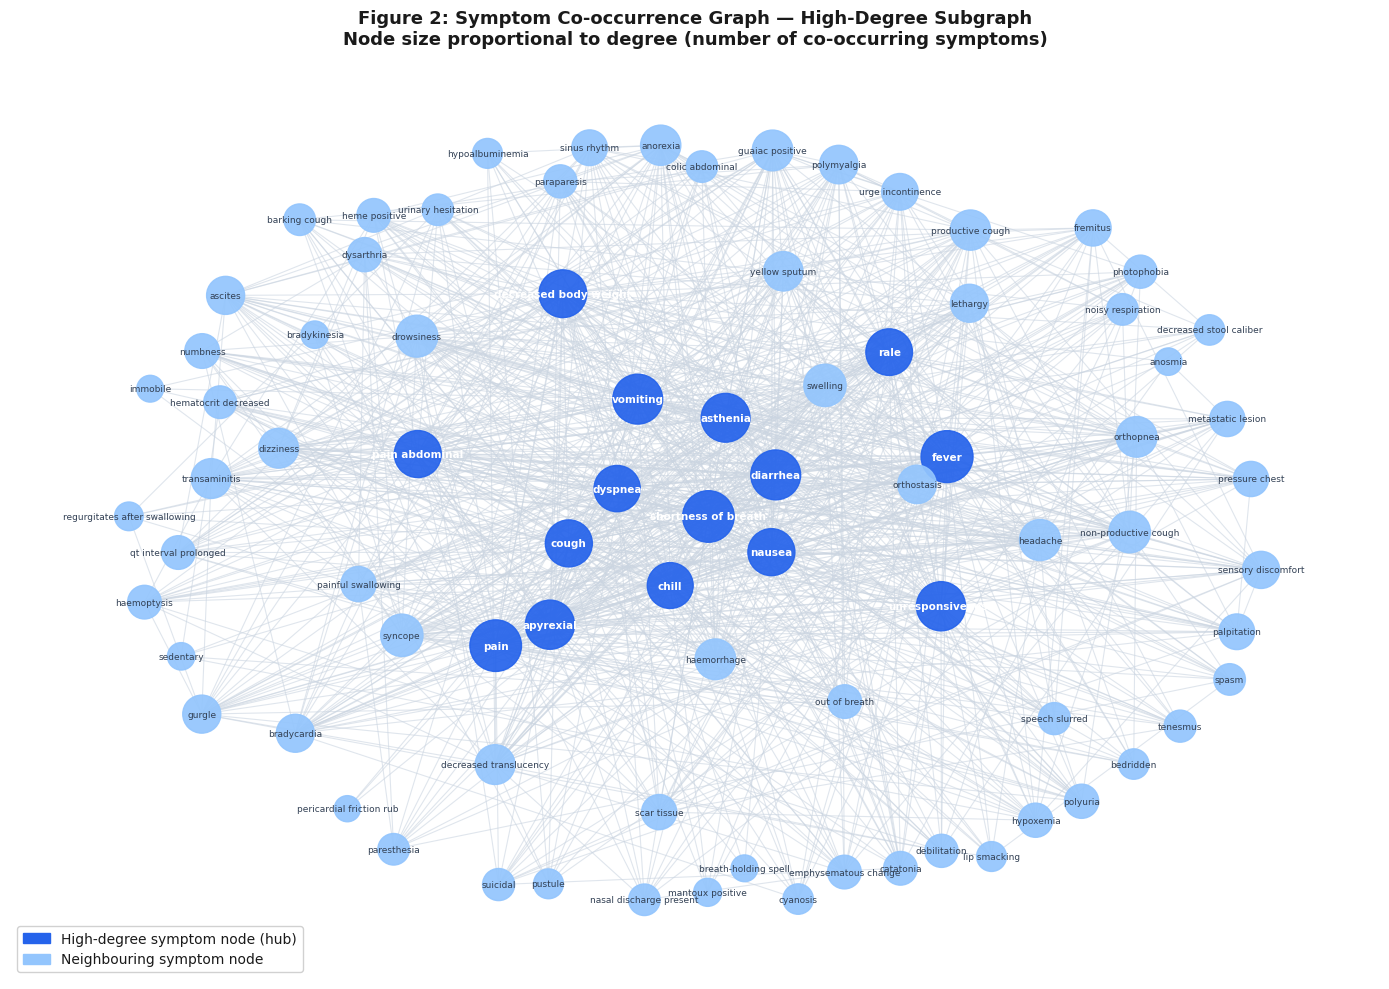

Saved → fig2_symptom_cooccurrence_subgraph.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

# ── Build NetworkX graph from edge_index ──────────────────────────────────
ei  = edge_index.cpu().numpy()
G   = nx.Graph()
G.add_edges_from(zip(ei[0], ei[1]))

idx2sym = {v: k for k, v in symptom2idx.items()}

# ── Pick top-15 highest-degree nodes as subgraph centers ──────────────────
degree_dict = dict(G.degree())
top_nodes   = sorted(degree_dict, key=degree_dict.get, reverse=True)[:15]

# Include their neighbours (1-hop) — cap to avoid overcrowding
neighbors = set(top_nodes)
for n in top_nodes:
    neighbors.update(list(G.neighbors(n))[:5])  # max 5 neighbours each
subgraph  = G.subgraph(neighbors).copy()

# ── Layout & visual properties ────────────────────────────────────────────
pos = nx.spring_layout(subgraph, seed=SEED, k=2.5)

degrees     = dict(subgraph.degree())
node_sizes  = [300 + degrees[n] * 18  for n in subgraph.nodes()]
node_colors = ['#2563EB' if n in top_nodes else '#93C5FD'
               for n in subgraph.nodes()]
node_alpha  = [1.0 if n in top_nodes else 0.75
               for n in subgraph.nodes()]

labels = {n: idx2sym.get(n, str(n)).replace('_', '\n')
          for n in subgraph.nodes()}

# ── Draw ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
ax.set_facecolor('white')

# Edges
nx.draw_networkx_edges(subgraph, pos,
                       edge_color='#CBD5E1',
                       width=0.8, alpha=0.6, ax=ax)

# Nodes
nx.draw_networkx_nodes(subgraph, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       alpha=0.92, ax=ax)

# Labels — only on high-degree nodes to avoid clutter
top_labels = {n: labels[n] for n in top_nodes}
nx.draw_networkx_labels(subgraph, pos,
                        labels=top_labels,
                        font_size=7.5,
                        font_color='white',
                        font_weight='bold', ax=ax)

# Neighbour labels slightly offset
nbr_labels = {n: labels[n] for n in subgraph.nodes() if n not in top_nodes}
nx.draw_networkx_labels(subgraph, pos,
                        labels=nbr_labels,
                        font_size=6.5,
                        font_color='#334155', ax=ax)

# ── Legend & title ────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color='#2563EB', label='High-degree symptom node (hub)'),
    mpatches.Patch(color='#93C5FD', label='Neighbouring symptom node'),
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=10, frameon=True, framealpha=0.9)

ax.set_title('Figure 2: Symptom Co-occurrence Graph — High-Degree Subgraph\n'
             'Node size proportional to degree (number of co-occurring symptoms)',
             fontsize=13, fontweight='bold', pad=16, color='#1a1a1a')
ax.axis('off')

plt.tight_layout()
plt.savefig('fig2_symptom_cooccurrence_subgraph.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig2_symptom_cooccurrence_subgraph.png")

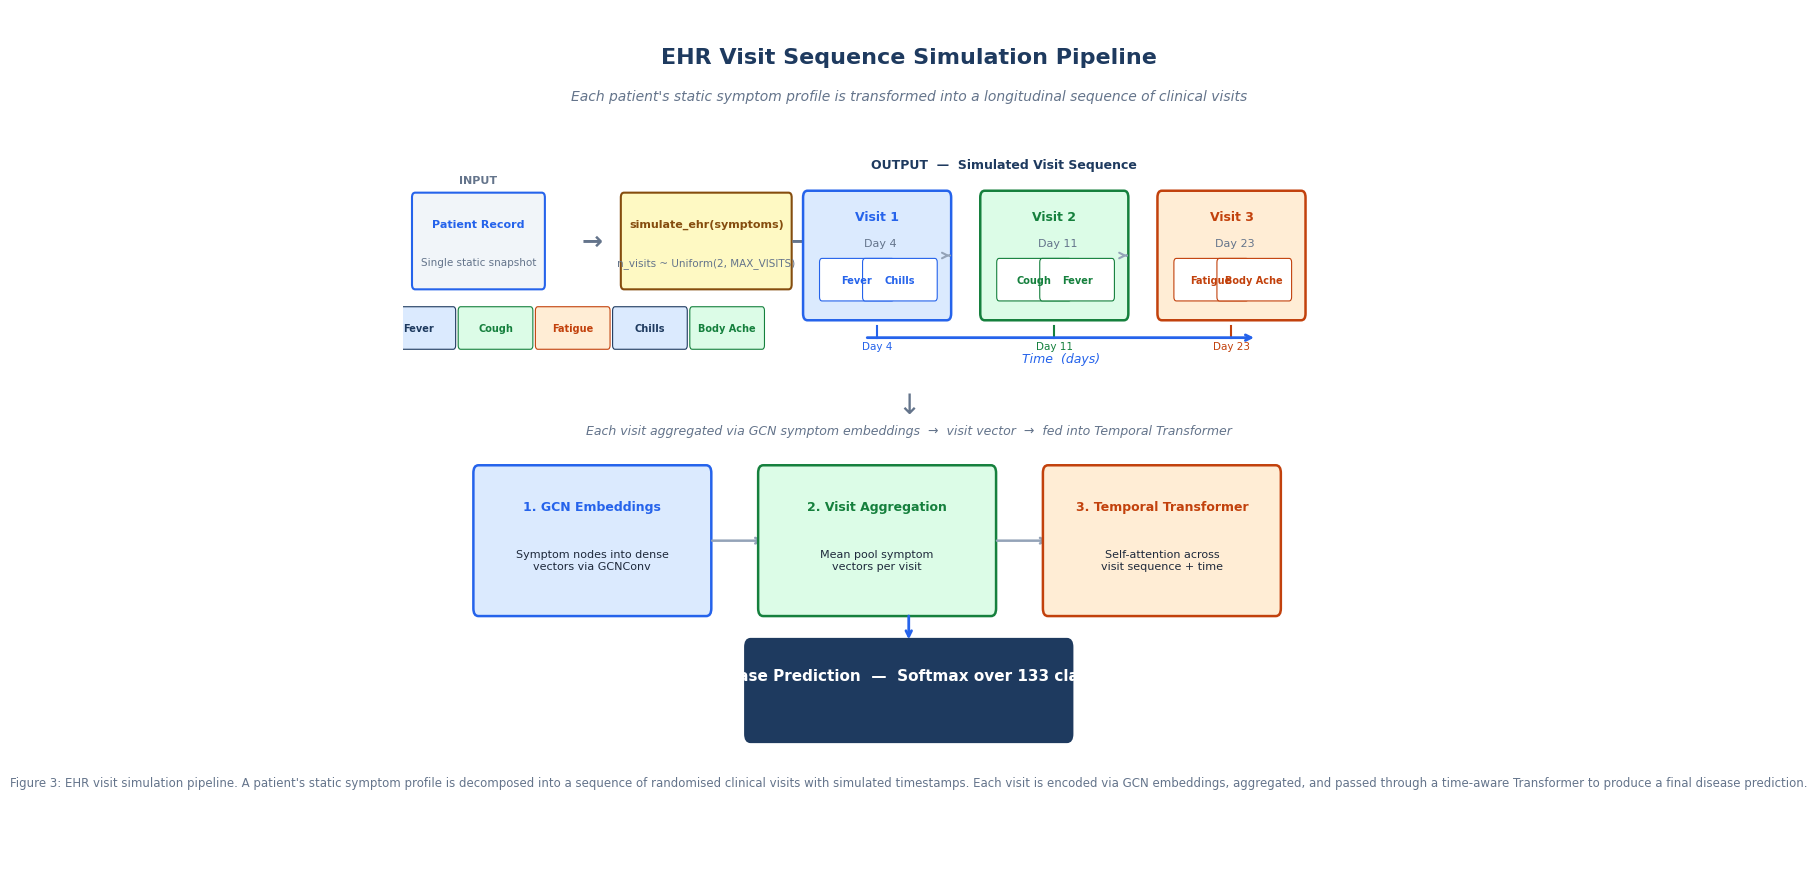

Saved -> fig3_ehr_simulation_diagram.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np

fig, ax = plt.subplots(figsize=(16, 9), facecolor='white')
ax.set_facecolor('white')
ax.axis('off')
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)

# ── Colors ────────────────────────────────────────────────────────────────
C_HEADER  = '#1E3A5F'
C_BLUE    = '#2563EB'
C_LBLUE   = '#DBEAFE'
C_GREEN   = '#15803D'
C_LGREEN  = '#DCFCE7'
C_ORANGE  = '#C2410C'
C_LORANGE = '#FFEDD5'
C_GREY    = '#F1F5F9'
C_DARK    = '#1E293B'
C_MID     = '#64748B'

# ── Title ─────────────────────────────────────────────────────────────────
ax.text(8, 8.5, 'EHR Visit Sequence Simulation Pipeline',
        ha='center', va='center', fontsize=16, fontweight='bold',
        color=C_HEADER)
ax.text(8, 8.1, "Each patient's static symptom profile is transformed into "
                "a longitudinal sequence of clinical visits",
        ha='center', va='center', fontsize=10, color=C_MID, style='italic')

# ── Helper functions ──────────────────────────────────────────────────────
def draw_box(ax, x, y, w, h, color, lcolor, label, sublabel=None, fontsize=9):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.05",
                         facecolor=color, edgecolor=lcolor,
                         linewidth=1.5, zorder=3)
    ax.add_patch(box)
    ax.text(x, y + (0.18 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=lcolor, zorder=4)
    if sublabel:
        ax.text(x, y - 0.22, sublabel,
                ha='center', va='center', fontsize=7.5,
                color=C_MID, zorder=4)

def draw_arrow(ax, x1, x2, y, color='#94A3B8'):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.8), zorder=5)

def draw_symptom_chip(ax, x, y, text, color='#DBEAFE', tcolor='#1E3A5F'):
    box = FancyBboxPatch((x - 0.55, y - 0.18), 1.1, 0.36,
                         boxstyle="round,pad=0.04",
                         facecolor=color, edgecolor=tcolor,
                         linewidth=0.8, zorder=4)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=7, color=tcolor, fontweight='bold', zorder=5)

# ══════════════════════════════════════════════════════════════════════════
# ROW 1 — Input patient
# ══════════════════════════════════════════════════════════════════════════
ax.text(1.2, 7.2, 'INPUT', ha='center', fontsize=8,
        fontweight='bold', color=C_MID)
draw_box(ax, 1.2, 6.6, 2.0, 0.9, C_GREY, C_BLUE,
         'Patient Record', 'Single static snapshot', fontsize=8)

syms_example = ['Fever', 'Cough', 'Fatigue', 'Chills', 'Body Ache']
chip_colors  = ['#DBEAFE','#DCFCE7','#FFEDD5','#DBEAFE','#DCFCE7']
chip_tcols   = ['#1E3A5F','#15803D','#C2410C','#1E3A5F','#15803D']
for i, (s, cc, tc) in enumerate(zip(syms_example, chip_colors, chip_tcols)):
    draw_symptom_chip(ax, 0.25 + i * 1.22, 5.7, s, cc, tc)

ax.text(3.0, 6.6, u'\u2192', fontsize=18, color=C_MID,
        ha='center', va='center', fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════
# ROW 1 — Simulation step
# ══════════════════════════════════════════════════════════════════════════
draw_box(ax, 4.8, 6.6, 2.6, 0.9, '#FEF9C3', '#854D0E',
         'simulate_ehr(symptoms)',
         'n_visits ~ Uniform(2, MAX_VISITS)', fontsize=8)

ax.text(6.3, 6.6, u'\u2192', fontsize=18, color=C_MID,
        ha='center', va='center', fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════
# ROW 1 — Output visits
# ══════════════════════════════════════════════════════════════════════════
ax.text(9.5, 7.35, 'OUTPUT  —  Simulated Visit Sequence',
        ha='center', fontsize=9, fontweight='bold', color=C_HEADER)

visits = [
    ('Visit 1', 'Day 4',  ['Fever', 'Chills'],      C_LBLUE,   C_BLUE),
    ('Visit 2', 'Day 11', ['Cough', 'Fever'],        C_LGREEN,  C_GREEN),
    ('Visit 3', 'Day 23', ['Fatigue', 'Body Ache'],  C_LORANGE, C_ORANGE),
]

vx_start = 7.5
for i, (vname, day, vsyms, bc, tc) in enumerate(visits):
    vx = vx_start + i * 2.8

    vbox = FancyBboxPatch((vx - 1.1, 5.85), 2.2, 1.2,
                          boxstyle="round,pad=0.07",
                          facecolor=bc, edgecolor=tc,
                          linewidth=1.8, zorder=3)
    ax.add_patch(vbox)

    ax.text(vx, 6.85, vname, ha='center', va='center',
            fontsize=9, fontweight='bold', color=tc, zorder=4)
    ax.text(vx, 6.58, f'  {day}', ha='center', va='center',
            fontsize=8, color=C_MID, zorder=4)

    for j, sym in enumerate(vsyms):
        draw_symptom_chip(ax, vx - 0.32 + j * 0.68, 6.2, sym, 'white', tc)

    if i < len(visits) - 1:
        ax.annotate('', xy=(vx + 1.15, 6.45), xytext=(vx + 1.1, 6.45),
                    arrowprops=dict(arrowstyle='->', color='#94A3B8', lw=1.5))

# Timeline arrow
ax.annotate('', xy=(13.5, 5.6), xytext=(7.3, 5.6),
            arrowprops=dict(arrowstyle='->', color=C_BLUE, lw=2.0))
ax.text(10.4, 5.35, 'Time  (days)',
        ha='center', fontsize=9, color=C_BLUE, style='italic')
for i, (_, day, _, _, tc) in enumerate(visits):
    vx = vx_start + i * 2.8
    ax.plot([vx, vx], [5.6, 5.72], color=tc, lw=1.5)
    ax.text(vx, 5.48, day, ha='center', fontsize=7.5, color=tc)

# ══════════════════════════════════════════════════════════════════════════
# ROW 2 — Processing steps
# ══════════════════════════════════════════════════════════════════════════
ax.text(8, 4.9, u'\u2193', fontsize=20, ha='center', color=C_MID, va='center')
ax.text(8, 4.6, 'Each visit aggregated via GCN symptom embeddings  '
                u'\u2192  visit vector  \u2192  fed into Temporal Transformer',
        ha='center', fontsize=9, color=C_MID, style='italic')

steps = [
    ('1. GCN Embeddings',      'Symptom nodes into dense\nvectors via GCNConv',   C_LBLUE,   C_BLUE),
    ('2. Visit Aggregation',   'Mean pool symptom\nvectors per visit',             C_LGREEN,  C_GREEN),
    ('3. Temporal Transformer','Self-attention across\nvisit sequence + time',     C_LORANGE, C_ORANGE),
]
for i, (title, desc, bc, tc) in enumerate(steps):
    bx = 3.0 + i * 4.5
    sbox = FancyBboxPatch((bx - 1.8, 2.8), 3.6, 1.4,
                          boxstyle="round,pad=0.08",
                          facecolor=bc, edgecolor=tc,
                          linewidth=1.8, zorder=3)
    ax.add_patch(sbox)
    ax.text(bx, 3.85, title, ha='center', va='center',
            fontsize=9, fontweight='bold', color=tc, zorder=4)
    ax.text(bx, 3.3, desc, ha='center', va='center',
            fontsize=8, color=C_DARK, zorder=4)
    if i < len(steps) - 1:
        ax.annotate('', xy=(bx + 2.75, 3.5), xytext=(bx + 1.85, 3.5),
                    arrowprops=dict(arrowstyle='->', color='#94A3B8', lw=1.8))

# ══════════════════════════════════════════════════════════════════════════
# ROW 3 — Output
# ══════════════════════════════════════════════════════════════════════════
ax.annotate('', xy=(8, 2.45), xytext=(8, 2.75),
            arrowprops=dict(arrowstyle='->', color=C_BLUE, lw=2.0))

out_box = FancyBboxPatch((5.5, 1.5), 5.0, 0.9,
                         boxstyle="round,pad=0.08",
                         facecolor='#1E3A5F', edgecolor='#1E3A5F',
                         linewidth=2, zorder=3)
ax.add_patch(out_box)
ax.text(8, 2.1, f'Disease Prediction  —  Softmax over {NUM_CLASSES} classes',
        ha='center', va='center', fontsize=11,
        fontweight='bold', color='white', zorder=4)

# ══════════════════════════════════════════════════════════════════════════
# Caption
# ══════════════════════════════════════════════════════════════════════════
ax.text(8, 1.0,
        "Figure 3: EHR visit simulation pipeline. A patient's static symptom profile is "
        "decomposed into a sequence of randomised clinical visits with simulated timestamps. "
        "Each visit is encoded via GCN embeddings, aggregated, "
        "and passed through a time-aware Transformer to produce a final disease prediction.",
        ha='center', va='center', fontsize=8.5, color=C_MID,
        linespacing=1.6)

plt.tight_layout()
plt.savefig('fig3_ehr_simulation_diagram.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved -> fig3_ehr_simulation_diagram.png")

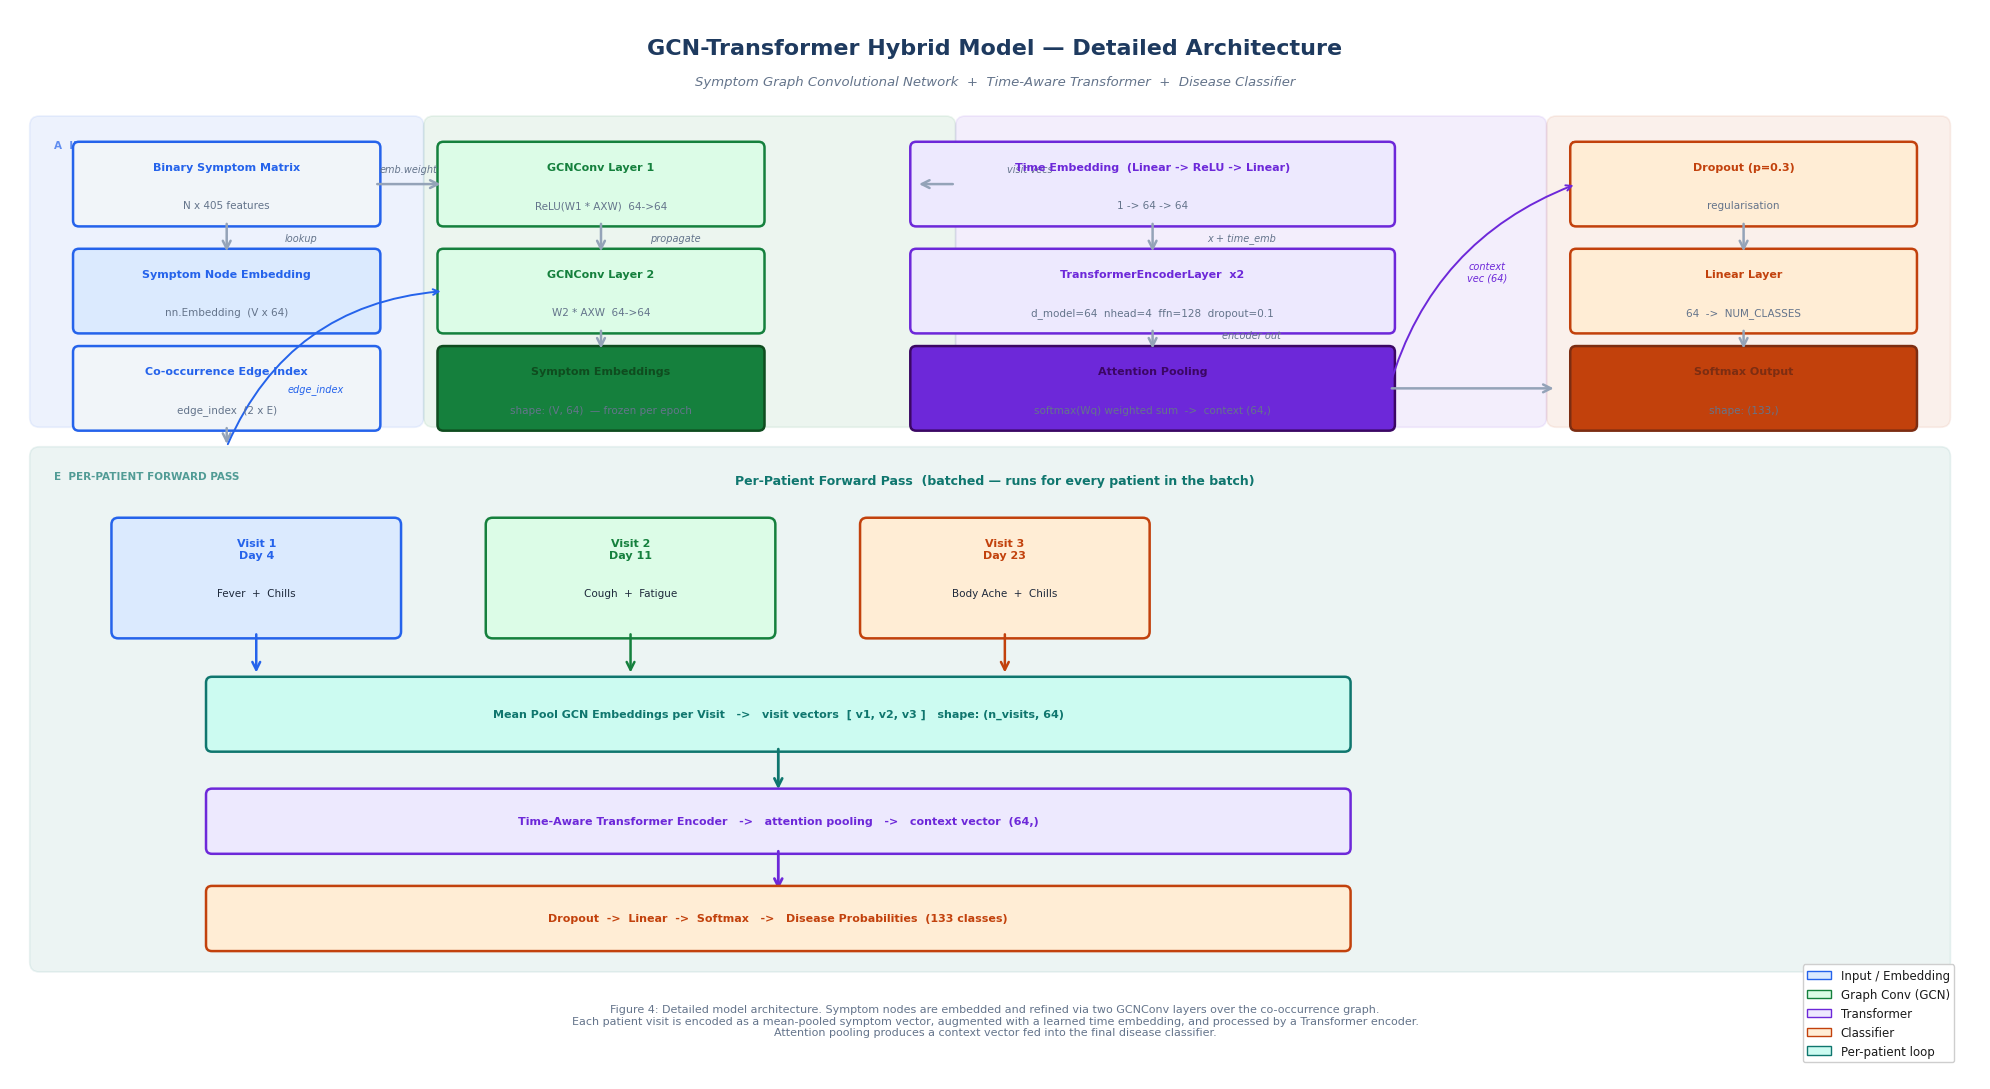

Saved -> fig4_model_architecture.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(20, 11), facecolor='white')
ax.set_facecolor('white')
ax.axis('off')
ax.set_xlim(0, 20)
ax.set_ylim(0, 11)

# ── Colors ────────────────────────────────────────────────────────────────
C_HEADER  = '#1E3A5F'
C_BLUE    = '#2563EB'
C_LBLUE   = '#DBEAFE'
C_GREEN   = '#15803D'
C_LGREEN  = '#DCFCE7'
C_ORANGE  = '#C2410C'
C_LORANGE = '#FFEDD5'
C_PURPLE  = '#6D28D9'
C_LPURPLE = '#EDE9FE'
C_RED     = '#DC2626'
C_LRED    = '#FEE2E2'
C_GREY    = '#F1F5F9'
C_DARK    = '#1E293B'
C_MID     = '#64748B'
C_TEAL    = '#0F766E'
C_LTEAL   = '#CCFBF1'

# ── Helpers ───────────────────────────────────────────────────────────────
def box(ax, x, y, w, h, fc, ec, title, sub=None, tsize=9, ssize=7.5):
    p = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle="round,pad=0.06",
                       facecolor=fc, edgecolor=ec,
                       linewidth=1.8, zorder=3)
    ax.add_patch(p)
    ty = y + (0.18 if sub else 0)
    ax.text(x, ty, title, ha='center', va='center',
            fontsize=tsize, fontweight='bold', color=ec, zorder=4)
    if sub:
        ax.text(x, y - 0.22, sub, ha='center', va='center',
                fontsize=ssize, color=C_MID, zorder=4)

def arrow(ax, x1, y1, x2, y2, color='#94A3B8', lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, mutation_scale=14))

def label(ax, x, y, txt, size=8, color=C_MID, bold=False, italic=False):
    ax.text(x, y, txt, ha='center', va='center', fontsize=size,
            color=color,
            fontweight='bold' if bold else 'normal',
            style='italic' if italic else 'normal')

def section_bg(ax, x, y, w, h, color, alpha=0.08, label_txt=None):
    p = FancyBboxPatch((x, y), w, h,
                       boxstyle="round,pad=0.1",
                       facecolor=color, edgecolor=color,
                       linewidth=1.2, alpha=alpha, zorder=1)
    ax.add_patch(p)
    if label_txt:
        ax.text(x + 0.15, y + h - 0.15, label_txt,
                ha='left', va='top', fontsize=7.5,
                color=color, fontweight='bold', alpha=0.7, zorder=2)

# ══════════════════════════════════════════════════════════════════════════
# TITLE
# ══════════════════════════════════════════════════════════════════════════
label(ax, 10, 10.6, 'GCN-Transformer Hybrid Model — Detailed Architecture',
      size=16, color=C_HEADER, bold=True)
label(ax, 10, 10.25,
      'Symptom Graph Convolutional Network  +  Time-Aware Transformer  +  Disease Classifier',
      size=9.5, color=C_MID, italic=True)

# ══════════════════════════════════════════════════════════════════════════
# SECTION BACKGROUNDS
# ══════════════════════════════════════════════════════════════════════════
section_bg(ax, 0.3,  6.8, 3.8, 3.0, C_BLUE,   label_txt='A  INPUT')
section_bg(ax, 4.3,  6.8, 5.2, 3.0, C_GREEN,  label_txt='B  SYMPTOM GCN')
section_bg(ax, 9.7,  6.8, 5.8, 3.0, C_PURPLE, label_txt='C  TEMPORAL TRANSFORMER')
section_bg(ax, 15.7, 6.8, 3.9, 3.0, C_ORANGE, label_txt='D  CLASSIFIER')

section_bg(ax, 0.3,  1.2, 19.3, 5.2, C_TEAL,  label_txt='E  PER-PATIENT FORWARD PASS')

# ══════════════════════════════════════════════════════════════════════════
# A — INPUT
# ══════════════════════════════════════════════════════════════════════════
box(ax, 2.2, 9.2, 3.0, 0.75, C_GREY,   C_BLUE,
    'Binary Symptom Matrix', f'N x {405} features', tsize=8)
box(ax, 2.2, 8.1, 3.0, 0.75, C_LBLUE,  C_BLUE,
    'Symptom Node Embedding', 'nn.Embedding  (V x 64)', tsize=8)
box(ax, 2.2, 7.1, 3.0, 0.75, C_GREY,   C_BLUE,
    'Co-occurrence Edge Index', 'edge_index  (2 x E)', tsize=8)

arrow(ax, 2.2, 8.82, 2.2, 8.48)
label(ax, 2.95, 8.65, 'lookup', size=7, italic=True)

# ══════════════════════════════════════════════════════════════════════════
# B — SYMPTOM GCN
# ══════════════════════════════════════════════════════════════════════════
box(ax, 6.0, 9.2, 3.2, 0.75, C_LGREEN, C_GREEN,
    'GCNConv Layer 1', 'ReLU(W1 * AXW)  64->64', tsize=8)
box(ax, 6.0, 8.1, 3.2, 0.75, C_LGREEN, C_GREEN,
    'GCNConv Layer 2', 'W2 * AXW  64->64', tsize=8)
box(ax, 6.0, 7.1, 3.2, 0.75, C_GREEN,  '#0F4C1F',
    'Symptom Embeddings', 'shape: (V, 64)  — frozen per epoch', tsize=8)

arrow(ax, 2.2, 7.48, 2.2, 7.48)   # edge index label
arrow(ax, 3.7, 9.2,  4.4, 9.2)
arrow(ax, 6.0, 8.82, 6.0, 8.48)
arrow(ax, 6.0, 7.72, 6.0, 7.48)
label(ax, 4.05, 9.35, 'emb.weight', size=7, italic=True)
label(ax, 6.75, 8.65, 'propagate', size=7, italic=True)

# Edge index feeds into GCN
arrow(ax, 2.2, 6.72, 2.2, 6.5)
ax.annotate('', xy=(4.4, 8.1), xytext=(2.2, 6.5),
            arrowprops=dict(arrowstyle='->', color=C_BLUE,
                            lw=1.4, connectionstyle='arc3,rad=-0.3'))
label(ax, 3.1, 7.1, 'edge_index', size=7, color=C_BLUE, italic=True)

# ══════════════════════════════════════════════════════════════════════════
# C — TEMPORAL TRANSFORMER
# ══════════════════════════════════════════════════════════════════════════
box(ax, 11.6, 9.2, 4.8, 0.75, C_LPURPLE, C_PURPLE,
    'Time Embedding  (Linear -> ReLU -> Linear)', '1 -> 64 -> 64', tsize=8)
box(ax, 11.6, 8.1, 4.8, 0.75, C_LPURPLE, C_PURPLE,
    'TransformerEncoderLayer  x2',
    'd_model=64  nhead=4  ffn=128  dropout=0.1', tsize=8)
box(ax, 11.6, 7.1, 4.8, 0.75, C_PURPLE,  '#3B0764',
    'Attention Pooling',
    'softmax(Wq) weighted sum  ->  context (64,)', tsize=8)

arrow(ax, 9.6,  9.2,  9.2,  9.2)
arrow(ax, 11.6, 8.82, 11.6, 8.48)
arrow(ax, 11.6, 7.72, 11.6, 7.48)
label(ax, 10.35, 9.35, 'visit vecs', size=7, italic=True)
label(ax, 12.5,  8.65, 'x + time_emb', size=7, italic=True)
label(ax, 12.6,  7.65, 'encoder out', size=7, italic=True)

# ══════════════════════════════════════════════════════════════════════════
# D — CLASSIFIER
# ══════════════════════════════════════════════════════════════════════════
box(ax, 17.6, 9.2, 3.4, 0.75, C_LORANGE, C_ORANGE,
    'Dropout (p=0.3)', 'regularisation', tsize=8)
box(ax, 17.6, 8.1, 3.4, 0.75, C_LORANGE, C_ORANGE,
    'Linear Layer',    '64  ->  NUM_CLASSES', tsize=8)
box(ax, 17.6, 7.1, 3.4, 0.75, C_ORANGE,  '#7C2D12',
    'Softmax Output',  f'shape: ({NUM_CLASSES},)', tsize=8)

arrow(ax, 14.0, 7.1,  15.7, 7.1)
arrow(ax, 17.6, 6.72, 17.6, 6.72)
ax.annotate('', xy=(15.9, 9.2), xytext=(14.0, 7.1),
            arrowprops=dict(arrowstyle='->', color=C_PURPLE,
                            lw=1.4, connectionstyle='arc3,rad=-0.25'))
arrow(ax, 17.6, 8.82, 17.6, 8.48)
arrow(ax, 17.6, 7.72, 17.6, 7.48)
label(ax, 15.0, 8.3,  'context\nvec (64)', size=7, color=C_PURPLE, italic=True)

# ══════════════════════════════════════════════════════════════════════════
# E — PER-PATIENT FORWARD PASS (bottom section)
# ══════════════════════════════════════════════════════════════════════════
label(ax, 10, 6.15,
      'Per-Patient Forward Pass  (batched — runs for every patient in the batch)',
      size=9, color=C_TEAL, bold=True)

# Patient visits row
visit_data = [
    ('Visit 1\nDay 4',  ['Fever', 'Chills'],       C_LBLUE,   C_BLUE),
    ('Visit 2\nDay 11', ['Cough', 'Fatigue'],       C_LGREEN,  C_GREEN),
    ('Visit 3\nDay 23', ['Body Ache', 'Chills'],    C_LORANGE, C_ORANGE),
]

for i, (vname, vsyms, bc, tc) in enumerate(visit_data):
    vx = 2.5 + i * 3.8
    vbox = FancyBboxPatch((vx - 1.4, 4.6), 2.8, 1.1,
                          boxstyle="round,pad=0.07",
                          facecolor=bc, edgecolor=tc,
                          linewidth=1.8, zorder=3)
    ax.add_patch(vbox)
    label(ax, vx, 5.45, vname, size=8, color=tc, bold=True)
    sym_str = '  +  '.join(vsyms)
    label(ax, vx, 5.0, sym_str, size=7.5, color=C_DARK)

    # Arrow down to mean pool
    arrow(ax, vx, 4.6, vx, 4.15, color=tc)

# Mean pool box
box(ax, 7.8, 3.75, 11.5, 0.65, C_LTEAL, C_TEAL,
    'Mean Pool GCN Embeddings per Visit   ->   visit vectors  [ v1, v2, v3 ]   shape: (n_visits, 64)',
    tsize=8)

# Arrow to transformer
arrow(ax, 7.8, 3.42, 7.8, 2.95, color=C_TEAL, lw=2)

# Transformer mini
box(ax, 7.8, 2.65, 11.5, 0.55, C_LPURPLE, C_PURPLE,
    'Time-Aware Transformer Encoder   ->   attention pooling   ->   context vector  (64,)',
    tsize=8)

# Arrow to classifier
arrow(ax, 7.8, 2.37, 7.8, 1.92, color=C_PURPLE, lw=2)

# Final output
box(ax, 7.8, 1.65, 11.5, 0.55, C_LORANGE, C_ORANGE,
    f'Dropout  ->  Linear  ->  Softmax   ->   Disease Probabilities  ({NUM_CLASSES} classes)',
    tsize=8)

# ══════════════════════════════════════════════════════════════════════════
# LEGEND
# ══════════════════════════════════════════════════════════════════════════
legend_items = [
    mpatches.Patch(facecolor=C_LBLUE,   edgecolor=C_BLUE,   label='Input / Embedding'),
    mpatches.Patch(facecolor=C_LGREEN,  edgecolor=C_GREEN,  label='Graph Conv (GCN)'),
    mpatches.Patch(facecolor=C_LPURPLE, edgecolor=C_PURPLE, label='Transformer'),
    mpatches.Patch(facecolor=C_LORANGE, edgecolor=C_ORANGE, label='Classifier'),
    mpatches.Patch(facecolor=C_LTEAL,   edgecolor=C_TEAL,   label='Per-patient loop'),
]
ax.legend(handles=legend_items, loc='lower right',
          fontsize=8.5, frameon=True, framealpha=0.95,
          bbox_to_anchor=(0.99, 0.01))

# Caption
label(ax, 10, 0.6,
      "Figure 4: Detailed model architecture. Symptom nodes are embedded and refined via two GCNConv layers "
      "over the co-occurrence graph.\nEach patient visit is encoded as a mean-pooled symptom vector, "
      "augmented with a learned time embedding, and processed by a Transformer encoder.\n"
      "Attention pooling produces a context vector fed into the final disease classifier.",
      size=8, color=C_MID)

plt.tight_layout()
plt.savefig('fig4_model_architecture.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved -> fig4_model_architecture.png")

In [ ]:
import torch
import torch_geometric
import sklearn
import pandas as pd
import numpy as np

print("Python        :", "3.12")
print("PyTorch       :", torch.__version__)
print("PyTorch Geom  :", torch_geometric.__version__)
print("scikit-learn  :", sklearn.__version__)
print("pandas        :", pd.__version__)
print("NumPy         :", np.__version__)

Python        : 3.12
PyTorch       : 2.10.0+cpu
PyTorch Geom  : 2.7.0
scikit-learn  : 1.6.1
pandas        : 2.2.2
NumPy         : 2.0.2


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

# ── Proposed model ─────────────────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    sym_emb_final = model.gnn(edge_index)
    out_test, _   = model(X_test, sym_emb_final)
    preds_final   = out_test.argmax(1).cpu().numpy()

acc_main = accuracy_score(y_test, preds_final)
p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(
    y_test, preds_final, average='macro',    zero_division=0)
p_wt,  r_wt,  f_wt,  _ = precision_recall_fscore_support(
    y_test, preds_final, average='weighted', zero_division=0)

print("=" * 55)
print("PROPOSED MODEL")
print(f"  Accuracy          : {acc_main:.4f}")
print(f"  Macro    P/R/F1   : {p_mac:.4f} / {r_mac:.4f} / {f_mac:.4f}")
print(f"  Weighted P/R/F1   : {p_wt:.4f}  / {r_wt:.4f}  / {f_wt:.4f}")
print("=" * 55)

print("\nFULL PER-CLASS REPORT:")
print(classification_report(y_test, preds_final,
                             target_names=le.classes_, zero_division=0))

# ── Ablation results ───────────────────────────────────────────────────
if 'results' in locals():
    print("\nALL MODEL COMPARISON:")
    print(f"{'Model':<35} {'Acc':>6} {'Macro P':>8} {'Macro R':>8} {'Macro F1':>9}")
    print("-" * 70)
    for mn, (a, p, r, f) in results.items():
        print(f"{mn:<35} {a:>6.4f} {p:>8.4f} {r:>8.4f} {f:>9.4f}")
else:
    print("\nNOTE: Ablation results not found.")
    print("Please run the baseline comparison cell first, then re-run this.")

# ── Training history ───────────────────────────────────────────────────
print("\nTRAINING HISTORY (all epochs logged):")
for ep, ac in zip(epochs_logged, test_accs):
    print(f"  Epoch {ep:3d} -> Acc {ac:.4f}")
print(f"\nBest accuracy : {max(test_accs):.4f}")
print(f"Final epoch   : {epochs_logged[-1]}")

PROPOSED MODEL
  Accuracy          : 0.7743
  Macro    P/R/F1   : 0.7895 / 0.7813 / 0.7734
  Weighted P/R/F1   : 0.7959  / 0.7743  / 0.7746

FULL PER-CLASS REPORT:
                                      precision    recall  f1-score   support

            accident cerebrovascular       0.68      0.93      0.79        14
 acquired immuno-deficiency syndrome       0.70      0.74      0.72        19
                      adenocarcinoma       1.00      0.78      0.88        18
                            adhesion       1.00      0.94      0.97        17
                       affect labile       0.71      0.92      0.80        13
                 alzheimer's disease       0.93      0.72      0.81        18
                              anemia       0.80      0.84      0.82        19
                       anxiety state       0.69      0.45      0.55        20
                             aphasia       0.80      1.00      0.89        12
                           arthritis       0.67      0.

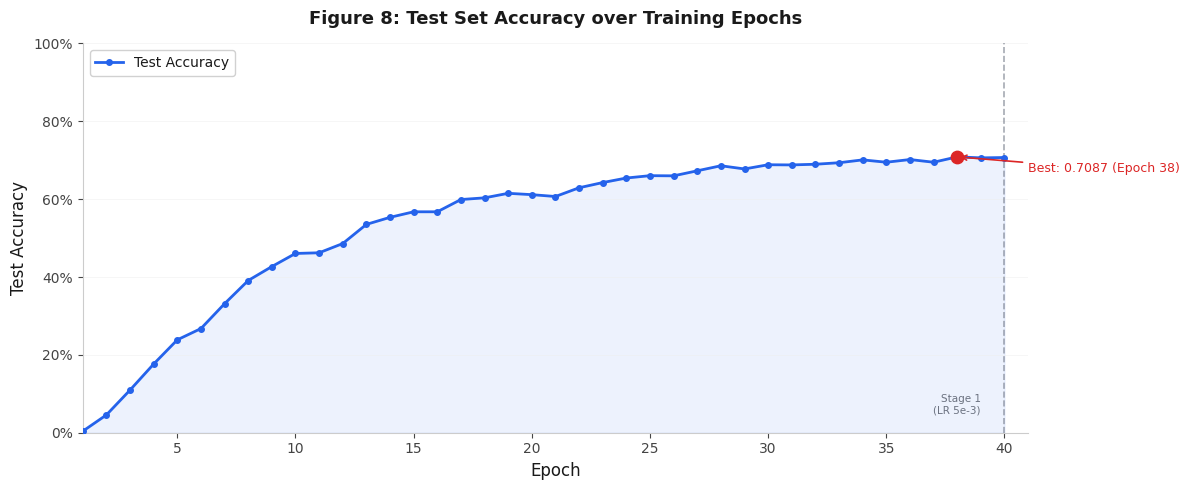

Saved -> fig8_test_accuracy.png


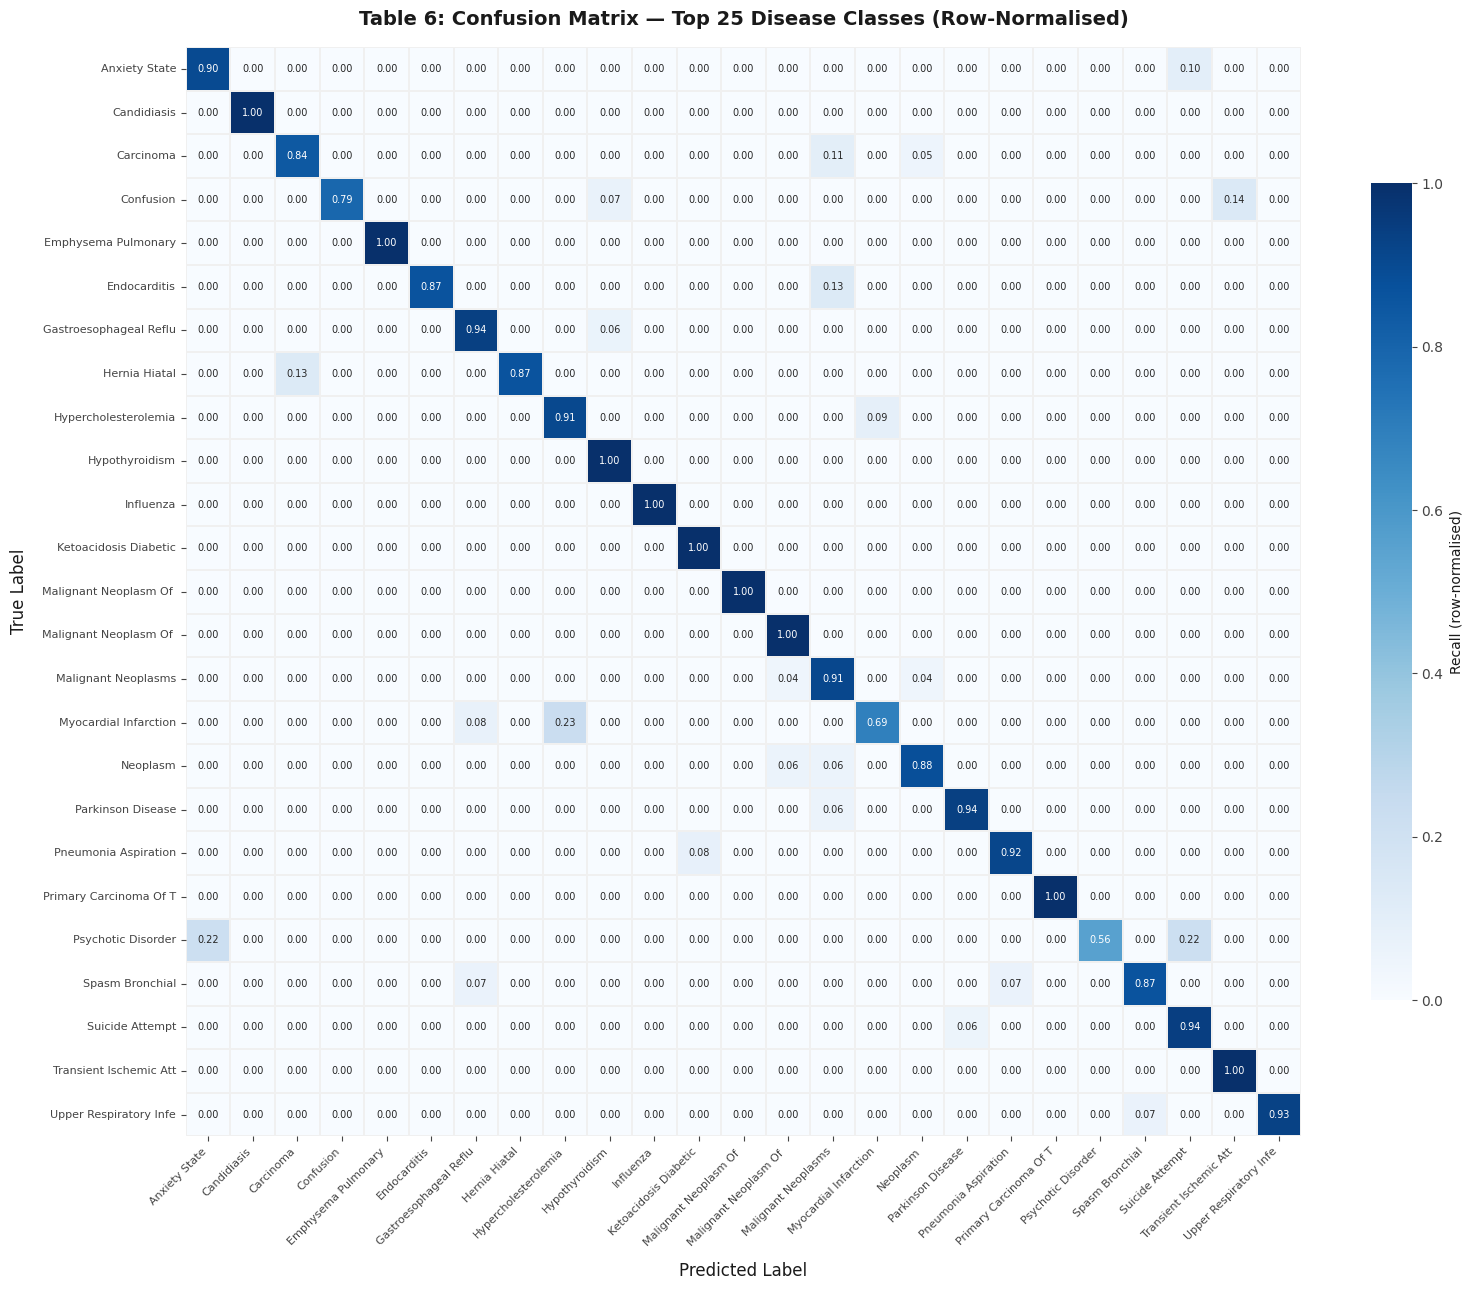

Saved -> fig_confusion_matrix.png


AttributeError: module 'matplotlib.patches' has no attribute 'Line2D'

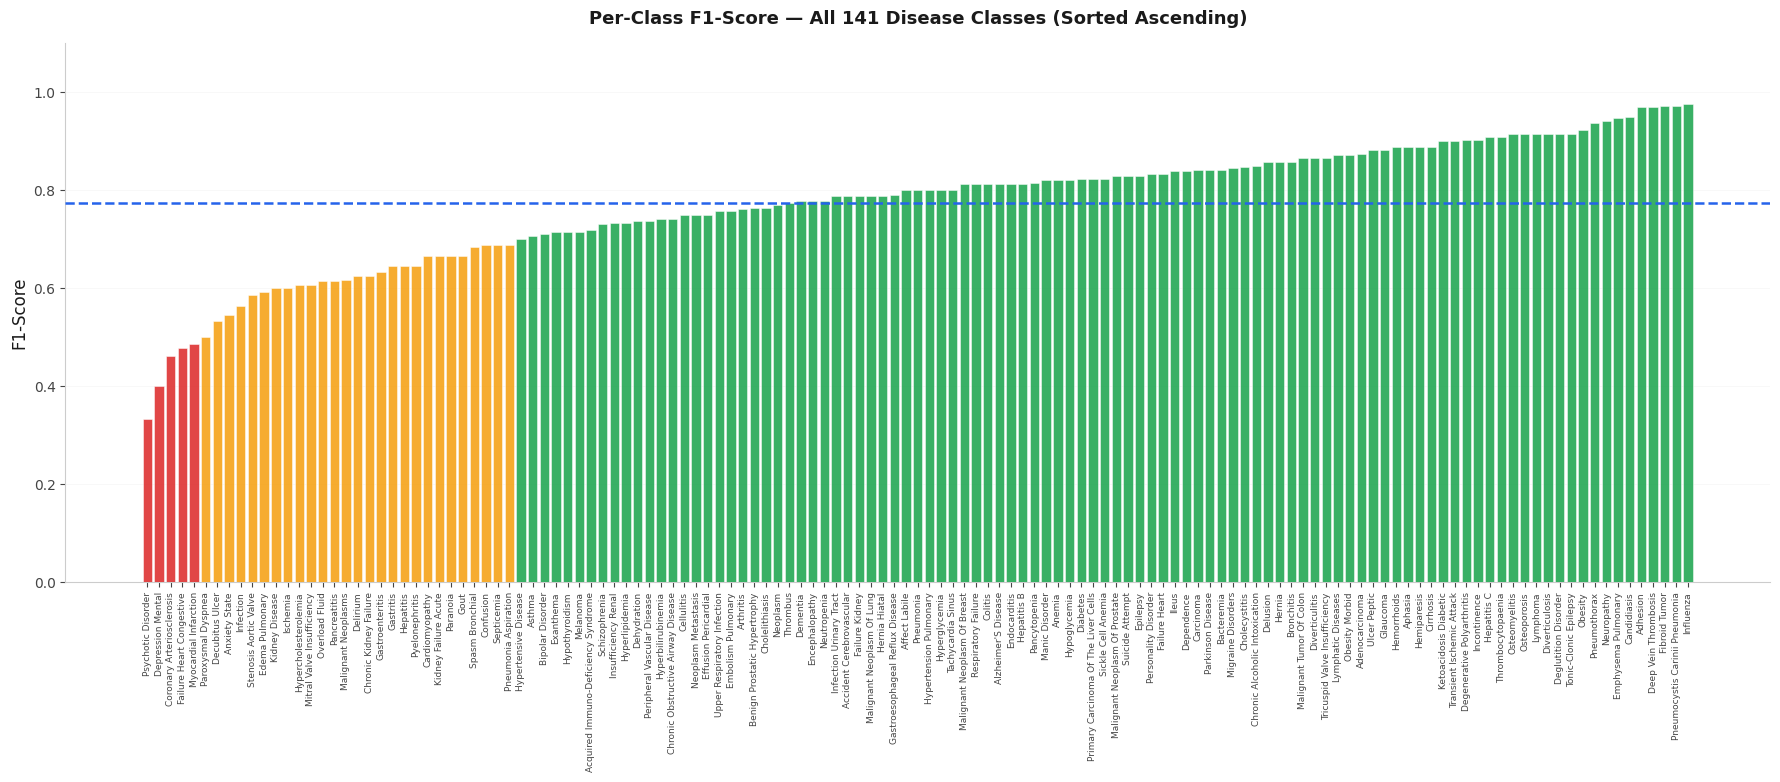

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#cccccc',
    'axes.labelcolor':   '#1a1a1a',
    'xtick.color':       '#444444',
    'ytick.color':       '#444444',
    'text.color':        '#1a1a1a',
    'grid.color':        '#eeeeee',
    'grid.linewidth':    0.7,
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
BLUE  = '#2563EB'
RED   = '#DC2626'
GREEN = '#16A34A'
GREY  = '#6B7280'

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 7 — Test Accuracy Over Epochs
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(epochs_logged, test_accs, color=BLUE, lw=2, marker='o',
        markersize=4, zorder=3, label='Test Accuracy')
ax.fill_between(epochs_logged, test_accs, alpha=0.08, color=BLUE)

# Mark best accuracy
best_idx = int(np.argmax(test_accs))
ax.scatter(epochs_logged[best_idx], test_accs[best_idx],
           color=RED, s=80, zorder=5)
ax.annotate(f"Best: {test_accs[best_idx]:.4f} (Epoch {epochs_logged[best_idx]})",
            xy=(epochs_logged[best_idx], test_accs[best_idx]),
            xytext=(epochs_logged[best_idx] + 3, test_accs[best_idx] - 0.04),
            fontsize=9, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

# Mark training stage boundaries
for stage_end, stage_label in [(40, 'Stage 1\n(LR 5e-3)'),
                                (60, 'Stage 2\n(LR 5e-4)'),
                                (100, 'Stage 3\n(LR 1e-4)')]:
    if stage_end <= max(epochs_logged):
        ax.axvline(stage_end, ls='--', color=GREY, lw=1.2, alpha=0.6)
        ax.text(stage_end - 1, 0.05, stage_label,
                ha='right', fontsize=7.5, color=GREY)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Figure 8: Test Set Accuracy over Training Epochs',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylim(0, 1.0)
ax.set_xlim(1, max(epochs_logged) + 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, axis='y', alpha=0.5)
ax.legend(fontsize=10, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig8_test_accuracy.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved -> fig8_test_accuracy.png")

# ══════════════════════════════════════════════════════════════════════════
# FIGURE — Confusion Matrix (Top 25 classes by support)
# ══════════════════════════════════════════════════════════════════════════
TOP_N = 25

top_cls_idx = np.argsort(np.bincount(np.array(y_test)))[-TOP_N:]
mask        = np.isin(y_test, top_cls_idx) & np.isin(preds_final, top_cls_idx)
yt_sub      = np.array(y_test)[mask]
yp_sub      = preds_final[mask]

remap  = {old: new for new, old in enumerate(sorted(top_cls_idx))}
yt_r   = np.array([remap[v] for v in yt_sub])
yp_r   = np.array([remap[v] for v in yp_sub])
names  = [le.classes_[i].title()[:22] for i in sorted(top_cls_idx)]

cm      = confusion_matrix(yt_r, yp_r)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            cmap='Blues',
            xticklabels=names, yticklabels=names,
            linewidths=0.3, linecolor='#f0f0f0',
            cbar_kws={'label': 'Recall (row-normalised)', 'shrink': 0.75},
            ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 7})

ax.set_title(f'Table 6: Confusion Matrix — Top {TOP_N} Disease Classes (Row-Normalised)',
             fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label',      fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)

plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved -> fig_confusion_matrix.png")

# ══════════════════════════════════════════════════════════════════════════
# FIGURE — Per-class F1 Bar Chart (all classes, sorted)
# ══════════════════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report

report    = classification_report(y_test, preds_final,
                                  target_names=le.classes_,
                                  output_dict=True, zero_division=0)
cls_names = [c for c in le.classes_
             if c in report and c not in
             ('accuracy', 'macro avg', 'weighted avg')]

f1s   = np.array([report[c]['f1-score']  for c in cls_names])
precs = np.array([report[c]['precision'] for c in cls_names])
recs  = np.array([report[c]['recall']    for c in cls_names])
order = np.argsort(f1s)  # ascending — worst to best left to right

cls_sorted  = [cls_names[i].title() for i in order]
f1_sorted   = f1s[order]
prec_sorted = precs[order]
rec_sorted  = recs[order]

# Colour bars by F1 tier
bar_colors = ['#DC2626' if f < 0.5 else
              '#F59E0B' if f < 0.7 else
              '#16A34A' for f in f1_sorted]

fig, ax = plt.subplots(figsize=(22, 7))
x = np.arange(len(cls_sorted))
bars = ax.bar(x, f1_sorted, color=bar_colors, alpha=0.85,
              edgecolor='white', linewidth=0.4, zorder=3)

# Macro F1 reference line
macro_f1 = report['macro avg']['f1-score']
ax.axhline(macro_f1, ls='--', color=BLUE, lw=1.8,
           label=f'Macro F1 = {macro_f1:.3f}', zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(cls_sorted, rotation=90, fontsize=6.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score — All 141 Disease Classes (Sorted Ascending)',
             fontsize=13, fontweight='bold', pad=14)
ax.grid(True, axis='y', alpha=0.4, zorder=0)

legend_patches = [
    mpatches.Patch(color='#DC2626', label='F1 < 0.50  (poor)'),
    mpatches.Patch(color='#F59E0B', label='0.50 ≤ F1 < 0.70  (moderate)'),
    mpatches.Patch(color='#16A34A', label='F1 ≥ 0.70  (good)'),
    mpatches.Line2D([0], [0], color=BLUE, ls='--', lw=2,
                    label=f'Macro F1 = {macro_f1:.3f}'),
]
ax.legend(handles=legend_patches, fontsize=9,
          frameon=True, framealpha=0.95, loc='upper left')

plt.tight_layout()
plt.savefig('fig_perclass_f1.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved -> fig_perclass_f1.png")

print("\nAll 3 figures saved:")
print("  fig8_test_accuracy.png")
print("  fig_confusion_matrix.png")
print("  fig_perclass_f1.png")